
# Multi-Offset Shift Head Hypothesis — Induction Head Experiments

This notebook tests the hypothesis (extending Elhage et al. 2021, *A Mathematical
Framework for Transformer Circuits*) that attention-only transformers deeper than
2 layers develop a **family of shift heads** at offsets `-1, -2, -3, ...` that get
K-composed together into induction heads, rather than relying on a single
previous-token (`-1`) head. This predicts:

- Longer repeated n-grams (bigram → trigram → quadgram) should require more
  offsets to be composed, so deeper models should keep solving them while
  shallow models degrade.
- If the context is locally noisy (a token inserted or substituted), a model
  with multiple shift heads should **route around** the corrupted offset and
  stay more accurate than a model relying on `-1` alone.
- Ablating a single shift head should cause a **graceful, partial** accuracy
  drop (redundancy) in deeper models, not a sharp collapse.

**Structure of this notebook:**
1. Setup & config
2. Generate the three experiment-phase datasets (isolated lengths / skip-noise / mixed)
3. A minimal training + evaluation harness for `AttentionOnlyTransformer`
4. Experiment 1 — isolated length sweep across model depth
5. Experiment 2 — skip/noise robustness sweep across model depth
6. Head-ablation study (tests the "graceful degradation" prediction)
7. Experiment 3 — mixed/multiplexed dataset + per-head attention-offset analysis
8. K-composition Frobenius-norm analysis (the paper's own method for detecting
   composed heads, reused here to look for `-1/-2/-3` shift-head families)

This notebook is meant to be **run end-to-end by you** — it is deliberately not
hyper-tuned. Epoch counts / dataset sizes are modest defaults so a full run
finishes in a reasonable time on a single GPU (or slowly on CPU); bump the
`CONFIG` values up if the models are underfitting before you draw conclusions
from the plots. All raw numbers needed for further analysis (per-order,
per-noise-type, per-head accuracies) are kept in plain Python dicts/DataFrames
so you can dig back into them after the fact.



## 1. Setup & config

We import the two files you already have (`generate_induction_datasets.py` for
data, `models.py` for the attention-only transformer) — keep them in the same
folder as this notebook.

**On "layers 0-4":** we sweep `num_layers` over `[0, 1, 2, 3, 4]`. `0` layers is
a literal degenerate control (pure token+position embedding, no attention at
all — it cannot do induction, so it should sit at chance accuracy). It's a
useful sanity check that the metric/harness itself isn't giving free accuracy.


In [1]:

import os
import sys
import json
import math
import itertools
from collections import defaultdict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

# make sure the two sibling files are importable regardless of cwd
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import generate_induction_datasets as gid   # your dataset generator (unmodified)
from models import AttentionOnlyTransformer  # your ablatable attention-only model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: running on CPU. Attention is O(seq_len^2) per layer, so each\n"
          "         extra layer/epoch/dataset multiplies wall-clock time fast.\n"
          "         If you're on Colab: Runtime -> Change runtime type -> GPU.\n"
          "         Until then, keep QUICK_TEST=True below and/or shrink seq_len.")
else:
    torch.backends.cudnn.benchmark = True  # let cuDNN pick fast kernels for our fixed shapes

torch.manual_seed(0)
np.random.seed(0)


device: cuda


In [2]:

CONFIG = {
    # --- data ---
    "vocab_size": 200,
    "seq_len": 256,
    "triggers_per_seq": (3, 6),      # min/max induction triggers per sequence

    # how many sequences per dataset. QUICK_TEST shrinks these a lot so you can
    # smoke-test the whole notebook fast before committing to a full run.
    "n_isolated": 4000,   # per order (bigram/trigram/quadgram), phase 1
    "n_skip": 4000,       # per noise type, phase 2
    "n_mixed": 8000,      # phase 3
    "train_frac": 0.9,

    # --- model ---
    "embed_dim": 128,
    "num_heads": 4,
    "layer_counts": [0, 1, 2, 3, 4],   # the depth sweep ("layers 0-4")

    # --- training ---
    "epochs": 8,
    "batch_size": 128,        # bigger batch = fewer python/optimizer-step round trips per epoch
    "eval_batch_size": 256,   # eval has no backward pass, so this can be larger than train batch_size
    "lr": 3e-4,
    "weight_decay": 0.0,
    "val_eval_every": 2,      # only run the (expensive) full induction-accuracy check every N epochs
    "val_subset_for_monitoring": 300,  # cap sequences used for the *mid-training* progress printout only

    "seed": 0,
}

QUICK_TEST = False  # flip to True for a fast smoke-test pass with tiny data/epochs/model

if QUICK_TEST:
    CONFIG["n_isolated"] = 400
    CONFIG["n_skip"] = 400
    CONFIG["n_mixed"] = 800
    CONFIG["epochs"] = 2
    CONFIG["seq_len"] = 128
    CONFIG["embed_dim"] = 64
    CONFIG["val_eval_every"] = 1
    CONFIG["layer_counts"] = [0, 1, 2, 4]  # still spans the range, just fewer points

CONFIG


{'vocab_size': 200,
 'seq_len': 256,
 'triggers_per_seq': (3, 6),
 'n_isolated': 4000,
 'n_skip': 4000,
 'n_mixed': 8000,
 'train_frac': 0.9,
 'embed_dim': 128,
 'num_heads': 4,
 'layer_counts': [0, 1, 2, 3, 4],
 'epochs': 8,
 'batch_size': 128,
 'eval_batch_size': 256,
 'lr': 0.0003,
 'weight_decay': 0.0,
 'val_eval_every': 2,
 'val_subset_for_monitoring': 300,
 'seed': 0}


## 2. Generate the datasets

We call `generate_induction_datasets.generate_dataset(...)` directly (same
function the CLI script uses under the hood) instead of shelling out, so
everything lives in-memory as numpy arrays + per-sequence event metadata.

Each *sequence* only ever contains triggers of the order/noise-type you asked
for — that's what keeps "isolated" meaningful even when we later concatenate
several isolated datasets together for training efficiency. The `events`
metadata is what lets `gid.induction_accuracy(...)` score a model exactly at
the induction query positions, filtered by `order=` and/or `noise_type=`, no
matter how the training mix was built.


In [3]:

def make_phase_dataset(order_choices, noise_type_choices, noise_type_probs,
                        n_total, seed):
    '''Thin wrapper around gid.generate_dataset with a train/val split,
    mirroring what the CLI script's _make_split does.'''
    n_train = int(n_total * CONFIG["train_frac"])
    n_val = n_total - n_train
    gen_kwargs = dict(
        seq_len=CONFIG["seq_len"], vocab_size=CONFIG["vocab_size"],
        order_choices=order_choices,
        noise_type_choices=noise_type_choices,
        noise_type_probs=noise_type_probs,
        triggers_per_seq=CONFIG["triggers_per_seq"],
    )
    tok_tr, ev_tr = gid.generate_dataset(n_sequences=n_train, seed=seed, **gen_kwargs)
    tok_va, ev_va = gid.generate_dataset(n_sequences=n_val, seed=seed + 1, **gen_kwargs)
    return tok_tr, ev_tr, tok_va, ev_va


# ---- Phase 1: isolated bigram / trigram / quadgram (no noise) ----
phase1 = {}
for order, name in [(2, "isolated_bigram"), (3, "isolated_trigram"), (4, "isolated_quadgram")]:
    phase1[name] = make_phase_dataset(
        order_choices=[order], noise_type_choices=[None], noise_type_probs=[1.0],
        n_total=CONFIG["n_isolated"], seed=CONFIG["seed"] + order,
    )
    print(f"[{name}] train seqs={len(phase1[name][0])}  val seqs={len(phase1[name][2])}")

# ---- Phase 2: quadgram clean / insertion / substitution (skip / noise sweep) ----
phase2 = {}
for noise_type, name in [(None, "skip_clean"), ("insertion", "skip_insertion"),
                          ("substitution", "skip_substitution")]:
    phase2[name] = make_phase_dataset(
        order_choices=[4], noise_type_choices=[noise_type], noise_type_probs=[1.0],
        n_total=CONFIG["n_skip"], seed=CONFIG["seed"] + 100 + (hash(str(noise_type)) % 1000),
    )
    print(f"[{name}] train seqs={len(phase2[name][0])}  val seqs={len(phase2[name][2])}")

# ---- Phase 3: mixed / multiplexed (random order + random noise per trigger) ----
mixed = make_phase_dataset(
    order_choices=[2, 3, 4],
    noise_type_choices=[None, "insertion", "substitution"],
    noise_type_probs=[0.5, 0.25, 0.25],
    n_total=CONFIG["n_mixed"], seed=CONFIG["seed"] + 500,
)
print(f"[mixed] train seqs={len(mixed[0])}  val seqs={len(mixed[2])}")


[isolated_bigram] train seqs=3600  val seqs=400
[isolated_trigram] train seqs=3600  val seqs=400
[isolated_quadgram] train seqs=3600  val seqs=400
[skip_clean] train seqs=3600  val seqs=400
[skip_insertion] train seqs=3600  val seqs=400
[skip_substitution] train seqs=3600  val seqs=400
[mixed] train seqs=7200  val seqs=800


In [4]:

# quick sanity peek — legend: U{n}=first occurrence of an order-n unit,
# C{n}=second-occurrence context, N=injected/substituted noise, A{n}!=answer token
gid.decode_and_print_examples(mixed[0], mixed[1], n_examples=2)


--- sequence 0 (5 triggers) ---
87 25 49 99 88 61 179 29 105[U3] 187[U3] 109[U3] 174 143 51 86 161 22 24 187 86 95 109[C3N] 187[C3] 109[A3!] 136 73 166 94 134 38 49 49 187 51[U3] 26[U3] 53[U3] 127 53 187 104 165 97 127 103 122 51[C3] 26[C3] 53[A3!] 188 174 177 34 9 190 99 197 169 28 173 85 55 79[U3] 18[U3] 140[U3] 170 95 31 55 50 164 197 130 7 20 126 79[C3] 18[C3] 140[A3!] 114 93 14 188 179 20 64[U4] 114[U4] 13[U4] 130[U4] 38 188 138 98 28 11 168 146 64[C4] 114[C4] 13[C4] 130[A4!] 4 37 108 28 72 117 121[U4] 158[U4] 89[U4] 168[U4] 100 31 18 99 24 151 175 121[C4] 27[C4N] 89[C4] 168[A4!] 66 178 101 141 139 172 126 40 77 194 107 139 187 85 0 52 4 38 43 56 165 33 98 101 175 89 8 7 101 141 46 127 78 88 156 8 164 182 74 59 59 2 147 139 133 106 62 151 4 62 83 46 37 138 96 6 198 164 30 159 176 70 76 92 171 43 66 148 81 95 27 79 199 110 172 82 66 80 78 183 148 160 146 134 187 180 185 58 169 102 178 62 110 22 55 64 125 187 94 3 37 7 140 10 140 85 55 98 69 24 92 120 109 177 127 172 52 65 179 156 1


## 3. Training + evaluation harness

- Standard next-token cross-entropy over the **whole** sequence (simplest,
  correct training signal — the induction triggers are a subset of positions
  within it).
- Evaluation reports two numbers: plain next-token accuracy (whole sequence,
  mostly filler — expect this to be low/uninteresting since filler is random)
  and **induction accuracy**, computed only at the logged `query_pos` /
  `answer_pos` pairs via `gid.induction_accuracy`, which is the metric that
  actually matters for this hypothesis and can be filtered by `order` /
  `noise_type`.


In [5]:

class TokenDataset(torch.utils.data.Dataset):
    '''Fixed-length token sequences; __getitem__ returns (input, target) where
    target is input shifted by one position (standard next-token LM setup).'''
    def __init__(self, tokens: np.ndarray):
        self.tokens = torch.as_tensor(tokens, dtype=torch.long)

    def __len__(self):
        return self.tokens.shape[0]

    def __getitem__(self, idx):
        seq = self.tokens[idx]
        return seq[:-1], seq[1:]


def make_loader(tokens, batch_size, shuffle):
    return torch.utils.data.DataLoader(TokenDataset(tokens), batch_size=batch_size, shuffle=shuffle)


from dataclasses import asdict, is_dataclass

def to_event_dicts(events_list):
    # gid.induction_accuracy indexes events as ev["query_pos"] (dict-style),
    # but gid.generate_dataset returns InductionEvent *dataclass* instances.
    # Convert once, idempotently (already-dict events pass through unchanged),
    # so we can freely call this both inside training (per-epoch val checks)
    # and again later on any events list without worrying about its origin.
    return [[asdict(ev) if is_dataclass(ev) else ev for ev in seq] for seq in events_list]


@torch.no_grad()
def predict_next_tokens(model, tokens: np.ndarray, ablation_mask=None, batch_size=None):
    '''Runs the model over `tokens` and returns argmax next-token predictions
    aligned to `tokens` itself (predicted[:, t] predicts tokens[:, t+1]),
    which is the shape gid.induction_accuracy expects.'''
    if batch_size is None:
        batch_size = CONFIG["eval_batch_size"]
    model.eval()
    all_preds = []
    tok_t = torch.as_tensor(tokens, dtype=torch.long)
    for i in range(0, tok_t.shape[0], batch_size):
        batch = tok_t[i:i + batch_size, :-1].to(DEVICE)
        logits, _ = model(batch, ablation_mask=ablation_mask)
        preds = logits.argmax(dim=-1).cpu()  # predicts position t+1 for each t
        # pad one column so predicted[:, t] lines up with tokens[:, t] convention
        # used by induction_accuracy (predicted_tokens[i, t] == guess for t+1)
        pad = torch.full((preds.shape[0], 1), -1, dtype=torch.long)
        all_preds.append(torch.cat([preds, pad], dim=1))
    return torch.cat(all_preds, dim=0).numpy()


def train_model(num_layers, train_tokens, val_tokens, val_events, tag=""):
    '''Trains one AttentionOnlyTransformer and returns (model, history_df).

    Speed notes: the *final* accuracy numbers used everywhere else in the
    notebook (phase1_df / phase2_df / mixed_df, ...) always run on the FULL
    val set after training finishes -- those are unaffected by anything here.
    What's tuned for speed is only the *mid-training progress printout*:
    it (a) reuses a small fixed subset of the val set (CONFIG
    val_subset_for_monitoring) instead of the whole thing, and (b) only runs
    every CONFIG["val_eval_every"] epochs. Both just make training faster to
    watch, they don't change what gets reported at the end.
    '''
    val_events = to_event_dicts(val_events)  # see note above -- induction_accuracy needs dict-style events
    model = AttentionOnlyTransformer(
        vocab_size=CONFIG["vocab_size"],
        embed_dim=CONFIG["embed_dim"],
        num_heads=CONFIG["num_heads"],
        num_layers=num_layers,
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    train_loader = make_loader(train_tokens, CONFIG["batch_size"], shuffle=True)

    n_monitor = min(CONFIG["val_subset_for_monitoring"], val_tokens.shape[0])
    monitor_tokens = val_tokens[:n_monitor]
    monitor_events = val_events[:n_monitor]

    history = []
    for epoch in range(CONFIG["epochs"]):
        model.train()
        total_loss, n_batches = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            logits, _ = model(x)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        is_last_epoch = epoch == CONFIG["epochs"] - 1
        if epoch % CONFIG["val_eval_every"] == 0 or is_last_epoch:
            preds = predict_next_tokens(model, monitor_tokens)
            val_acc = gid.induction_accuracy(preds, monitor_tokens, monitor_events)  # all triggers, unfiltered
            history.append({"epoch": epoch, "train_loss": avg_loss, "val_induction_acc": val_acc})
            print(f"[{tag} L={num_layers}] epoch {epoch}: loss={avg_loss:.4f}  val_induction_acc={val_acc:.3f}")
        else:
            history.append({"epoch": epoch, "train_loss": avg_loss, "val_induction_acc": np.nan})
            print(f"[{tag} L={num_layers}] epoch {epoch}: loss={avg_loss:.4f}  (val check skipped this epoch)")

    return model, pd.DataFrame(history)



## 4. Experiment 1 — isolated length sweep (bigram / trigram / quadgram) × depth

Each *sequence* in the training mix below only ever contains one fixed order
(that's how `phase1` was generated), so concatenating the three isolated
datasets keeps every trigger "isolated" at the metadata level while giving
each depth a single, efficient training run. We then read out accuracy
**separately per order** at eval time via `induction_accuracy(order=...)`,
which is exactly the isolation the events metadata exists for.

Prediction to look for in the resulting plot: shallow models (0-1 layers)
should do fine on bigrams but fall off sharply on trigram/quadgram, while
deeper models (3-4 layers) should hold up much better as order increases.


In [6]:

def concat_phase_datasets(dataset_dict, keys):
    '''Concatenates tokens/events across several (tok_tr, ev_tr, tok_va, ev_va) tuples.'''
    tok_tr = np.concatenate([dataset_dict[k][0] for k in keys], axis=0)
    ev_tr = sum([dataset_dict[k][1] for k in keys], [])
    tok_va = np.concatenate([dataset_dict[k][2] for k in keys], axis=0)
    ev_va = sum([dataset_dict[k][3] for k in keys], [])
    return tok_tr, ev_tr, tok_va, ev_va


p1_tok_tr, p1_ev_tr, p1_tok_va, p1_ev_va = concat_phase_datasets(
    phase1, ["isolated_bigram", "isolated_trigram", "isolated_quadgram"]
)

phase1_models = {}
phase1_histories = {}
for L in CONFIG["layer_counts"]:
    model, hist = train_model(L, p1_tok_tr, p1_tok_va, p1_ev_va, tag="phase1")
    phase1_models[L] = model
    phase1_histories[L] = hist


[phase1 L=0] epoch 0: loss=5.4203  val_induction_acc=0.004
[phase1 L=0] epoch 1: loss=5.3630  (val check skipped this epoch)
[phase1 L=0] epoch 2: loss=5.3344  val_induction_acc=0.004
[phase1 L=0] epoch 3: loss=5.3190  (val check skipped this epoch)
[phase1 L=0] epoch 4: loss=5.3103  val_induction_acc=0.005
[phase1 L=0] epoch 5: loss=5.3051  (val check skipped this epoch)
[phase1 L=0] epoch 6: loss=5.3019  val_induction_acc=0.004
[phase1 L=0] epoch 7: loss=5.2998  val_induction_acc=0.004
[phase1 L=1] epoch 0: loss=5.4204  val_induction_acc=0.007
[phase1 L=1] epoch 1: loss=5.3468  (val check skipped this epoch)
[phase1 L=1] epoch 2: loss=5.3020  val_induction_acc=0.006
[phase1 L=1] epoch 3: loss=5.2998  (val check skipped this epoch)
[phase1 L=1] epoch 4: loss=5.2993  val_induction_acc=0.007
[phase1 L=1] epoch 5: loss=5.2991  (val check skipped this epoch)
[phase1 L=1] epoch 6: loss=5.2989  val_induction_acc=0.007
[phase1 L=1] epoch 7: loss=5.2988  val_induction_acc=0.003
[phase1 L=2] e

In [7]:

# gid.induction_accuracy indexes events as ev["order"]/ev["noise_type"] (dict-style),
# so convert our in-memory InductionEvent dataclasses using the to_event_dicts
# helper defined in the training harness above.
p1_ev_va_dicts = to_event_dicts(p1_ev_va)

phase1_results = []  # rows: layer, order, accuracy
for L, model in phase1_models.items():
    preds = predict_next_tokens(model, p1_tok_va)
    for order in [2, 3, 4]:
        acc = gid.induction_accuracy(preds, p1_tok_va, p1_ev_va_dicts, order=order, noise_type="__any__")
        phase1_results.append({"num_layers": L, "order": order, "accuracy": acc})

phase1_df = pd.DataFrame(phase1_results)
phase1_df


,num_layers,order,accuracy
0,0,2,0.004499
1,0,3,0.008825
2,0,4,0.004942
3,1,2,0.002812
4,1,3,0.003861
5,1,4,0.003295
6,2,2,0.003375
7,2,3,0.003861
8,2,4,0.004942
9,3,2,0.003937


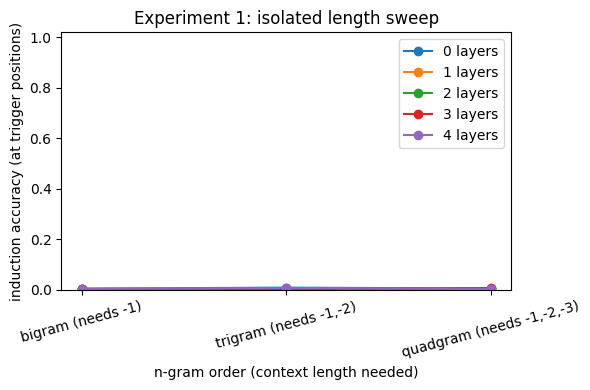

In [8]:

plt.figure(figsize=(6, 4))
for L in CONFIG["layer_counts"]:
    sub = phase1_df[phase1_df.num_layers == L].sort_values("order")
    plt.plot(sub["order"], sub["accuracy"], marker="o", label=f"{L} layers")
plt.xlabel("n-gram order (context length needed)")
plt.ylabel("induction accuracy (at trigger positions)")
plt.title("Experiment 1: isolated length sweep")
plt.xticks([2, 3, 4], ["bigram (needs -1)", "trigram (needs -1,-2)", "quadgram (needs -1,-2,-3)"], rotation=15)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()



## 5. Experiment 2 — skip/noise robustness sweep × depth

Same idea, held at order=4 (quadgram, the deepest context) while varying
whether the second-occurrence context is clean, has a token **inserted**
(shifts every offset after it by one — this is what specifically breaks a
pure `-1` head), or has a token **substituted** (wrong content, right
offset).

Prediction: if the multi-offset hypothesis holds, deeper models should show a
*smaller* accuracy gap between clean and insertion-noise than shallow models,
because they can fall back on `-2`/`-3` heads instead of only `-1`.


In [9]:

p2_tok_tr, p2_ev_tr, p2_tok_va, p2_ev_va = concat_phase_datasets(
    phase2, ["skip_clean", "skip_insertion", "skip_substitution"]
)

phase2_models = {}
phase2_histories = {}
for L in CONFIG["layer_counts"]:
    model, hist = train_model(L, p2_tok_tr, p2_tok_va, p2_ev_va, tag="phase2")
    phase2_models[L] = model
    phase2_histories[L] = hist


[phase2 L=0] epoch 0: loss=5.4218  val_induction_acc=0.004
[phase2 L=0] epoch 1: loss=5.3641  (val check skipped this epoch)
[phase2 L=0] epoch 2: loss=5.3350  val_induction_acc=0.003
[phase2 L=0] epoch 3: loss=5.3194  (val check skipped this epoch)
[phase2 L=0] epoch 4: loss=5.3105  val_induction_acc=0.005
[phase2 L=0] epoch 5: loss=5.3052  (val check skipped this epoch)
[phase2 L=0] epoch 6: loss=5.3019  val_induction_acc=0.004
[phase2 L=0] epoch 7: loss=5.2998  val_induction_acc=0.004
[phase2 L=1] epoch 0: loss=5.4191  val_induction_acc=0.008
[phase2 L=1] epoch 1: loss=5.3358  (val check skipped this epoch)
[phase2 L=1] epoch 2: loss=5.3013  val_induction_acc=0.005
[phase2 L=1] epoch 3: loss=5.2998  (val check skipped this epoch)
[phase2 L=1] epoch 4: loss=5.2993  val_induction_acc=0.002
[phase2 L=1] epoch 5: loss=5.2992  (val check skipped this epoch)
[phase2 L=1] epoch 6: loss=5.2990  val_induction_acc=0.005
[phase2 L=1] epoch 7: loss=5.2989  val_induction_acc=0.007
[phase2 L=2] e

In [10]:

p2_ev_va_dicts = to_event_dicts(p2_ev_va)

phase2_results = []  # rows: layer, noise_type, accuracy
noise_labels = {None: "clean", "insertion": "insertion", "substitution": "substitution"}
for L, model in phase2_models.items():
    preds = predict_next_tokens(model, p2_tok_va)
    for noise_type, label in noise_labels.items():
        acc = gid.induction_accuracy(preds, p2_tok_va, p2_ev_va_dicts, order=4, noise_type=noise_type)
        phase2_results.append({"num_layers": L, "noise_type": label, "accuracy": acc})

phase2_df = pd.DataFrame(phase2_results)
phase2_df


,num_layers,noise_type,accuracy
0,0,clean,0.007856
1,0,insertion,0.005051
2,0,substitution,0.006145
3,1,clean,0.007856
4,1,insertion,0.006734
5,1,substitution,0.006704
6,2,clean,0.005612
7,2,insertion,0.006173
8,2,substitution,0.003911
9,3,clean,0.004489


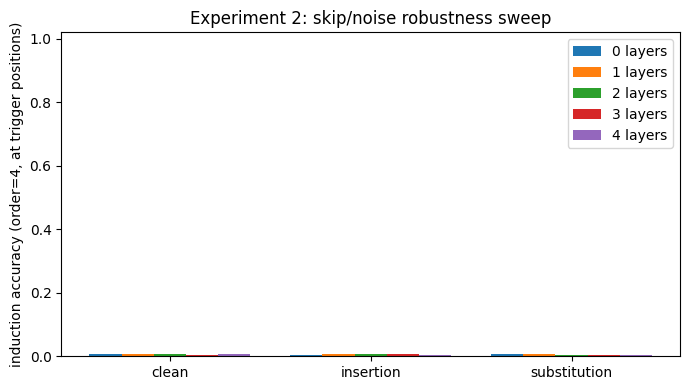

In [11]:

noise_order = ["clean", "insertion", "substitution"]
x = np.arange(len(noise_order))
width = 0.8 / len(CONFIG["layer_counts"])

plt.figure(figsize=(7, 4))
for i, L in enumerate(CONFIG["layer_counts"]):
    sub = phase2_df[phase2_df.num_layers == L].set_index("noise_type").reindex(noise_order)
    plt.bar(x + i * width, sub["accuracy"], width=width, label=f"{L} layers")
plt.xticks(x + width * (len(CONFIG["layer_counts"]) - 1) / 2, noise_order)
plt.ylabel("induction accuracy (order=4, at trigger positions)")
plt.title("Experiment 2: skip/noise robustness sweep")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()



## 6. Head-ablation study (redundancy vs. single point of failure)

Using the deepest phase-2 model, we zero out one `(layer, head)` at a time via
`AblatableSelfAttention`'s `ablation_mask` argument and re-measure induction
accuracy on clean vs. insertion-noise quadgrams.

- **Sharp collapse** on ablating one specific head (in both clean and noisy
  conditions) → consistent with a single dominant previous-token head.
- **Small, partial** accuracy loss spread across several heads, with noisy
  accuracy staying closer to clean accuracy than in Experiment 2's shallow
  models → consistent with the multi-offset / redundant shift-head hypothesis.


In [12]:

DEEPEST_L = max(CONFIG["layer_counts"])
ablation_model = phase2_models[DEEPEST_L]

def eval_with_ablation(model, tokens, events_dicts, ablation_mask, order=4):
    preds = predict_next_tokens(model, tokens, ablation_mask=ablation_mask)
    return {
        "clean": gid.induction_accuracy(preds, tokens, events_dicts, order=order, noise_type=None),
        "insertion": gid.induction_accuracy(preds, tokens, events_dicts, order=order, noise_type="insertion"),
        "substitution": gid.induction_accuracy(preds, tokens, events_dicts, order=order, noise_type="substitution"),
    }

baseline_scores = eval_with_ablation(ablation_model, p2_tok_va, p2_ev_va_dicts, ablation_mask=None)
print("baseline (no ablation):", baseline_scores)

ablation_rows = []
if DEEPEST_L > 0:
    for layer_idx in range(DEEPEST_L):
        for head_idx in range(CONFIG["num_heads"]):
            mask = {layer_idx: [head_idx]}
            scores = eval_with_ablation(ablation_model, p2_tok_va, p2_ev_va_dicts, ablation_mask=mask)
            for noise_type, acc in scores.items():
                ablation_rows.append({
                    "layer": layer_idx, "head": head_idx, "noise_type": noise_type,
                    "accuracy": acc, "drop_from_baseline": baseline_scores[noise_type] - acc,
                })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.sort_values("drop_from_baseline", ascending=False).head(20)


baseline (no ablation): {'clean': 0.006734006734006734, 'insertion': 0.004489337822671156, 'substitution': 0.003910614525139665}


,layer,head,noise_type,accuracy,drop_from_baseline
15,1,1,clean,0.003367,0.003367
30,2,2,clean,0.003928,0.002806
42,3,2,clean,0.004489,0.002245
47,3,3,substitution,0.001676,0.002235
25,2,0,insertion,0.002806,0.001684
40,3,1,insertion,0.002806,0.001684
9,0,3,clean,0.005051,0.001684
6,0,2,clean,0.005051,0.001684
33,2,3,clean,0.005051,0.001684
39,3,1,clean,0.005051,0.001684


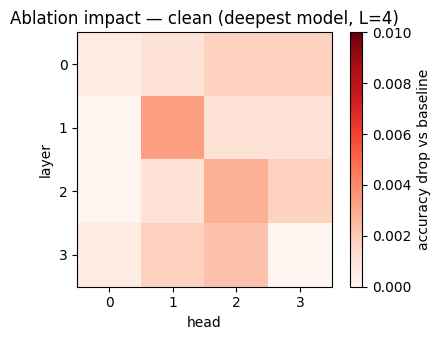

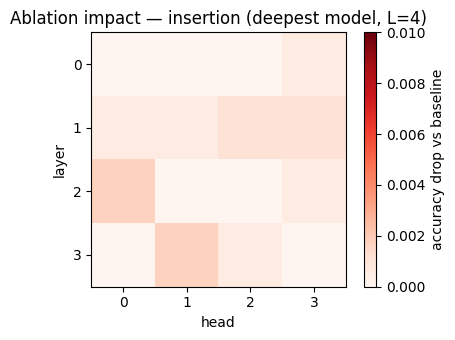

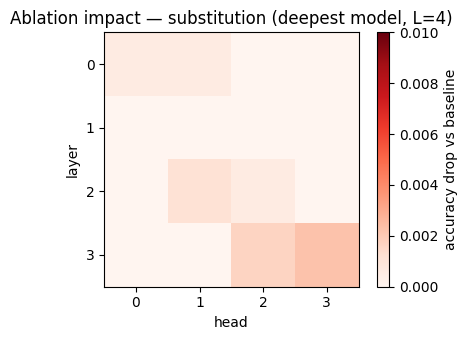

In [13]:

# heatmap of accuracy drop (clean condition) per (layer, head) -- large, isolated
# hotspots suggest a single dominant head; many small, spread-out values suggest
# redundant shift heads.
if len(ablation_df):
    for noise_type in ["clean", "insertion", "substitution"]:
        pivot = ablation_df[ablation_df.noise_type == noise_type].pivot(index="layer", columns="head", values="drop_from_baseline")
        plt.figure(figsize=(4.5, 3.5))
        plt.imshow(pivot.values, cmap="Reds", vmin=0, vmax=max(0.01, ablation_df.drop_from_baseline.max()))
        plt.colorbar(label="accuracy drop vs baseline")
        plt.xticks(range(pivot.shape[1]), pivot.columns)
        plt.yticks(range(pivot.shape[0]), pivot.index)
        plt.xlabel("head")
        plt.ylabel("layer")
        plt.title(f"Ablation impact — {noise_type} (deepest model, L={DEEPEST_L})")
        plt.tight_layout()
        plt.show()
else:
    print("DEEPEST_L == 0, nothing to ablate (no attention layers).")



## 7. Experiment 3 — mixed/multiplexed dataset

Trains directly on the chaotic mix (random order + random noise per trigger,
per the original spec), then breaks down accuracy by `order × noise_type` for
every depth — this is the "does a single induction head dynamically reroute"
setting rather than "does the model have separate specialized heads per
dataset type".


In [14]:

mixed_tok_tr, mixed_ev_tr, mixed_tok_va, mixed_ev_va = mixed

mixed_models = {}
mixed_histories = {}
for L in CONFIG["layer_counts"]:
    model, hist = train_model(L, mixed_tok_tr, mixed_tok_va, mixed_ev_va, tag="mixed")
    mixed_models[L] = model
    mixed_histories[L] = hist


[mixed L=0] epoch 0: loss=5.4338  val_induction_acc=0.000
[mixed L=0] epoch 1: loss=5.3856  (val check skipped this epoch)
[mixed L=0] epoch 2: loss=5.3558  val_induction_acc=0.001
[mixed L=0] epoch 3: loss=5.3366  (val check skipped this epoch)
[mixed L=0] epoch 4: loss=5.3239  val_induction_acc=0.004
[mixed L=0] epoch 5: loss=5.3154  (val check skipped this epoch)
[mixed L=0] epoch 6: loss=5.3096  val_induction_acc=0.004
[mixed L=0] epoch 7: loss=5.3054  val_induction_acc=0.004
[mixed L=1] epoch 0: loss=5.4296  val_induction_acc=0.003
[mixed L=1] epoch 1: loss=5.3796  (val check skipped this epoch)
[mixed L=1] epoch 2: loss=5.3248  val_induction_acc=0.004
[mixed L=1] epoch 3: loss=5.3015  (val check skipped this epoch)
[mixed L=1] epoch 4: loss=5.2998  val_induction_acc=0.002
[mixed L=1] epoch 5: loss=5.2993  (val check skipped this epoch)
[mixed L=1] epoch 6: loss=5.2990  val_induction_acc=0.002
[mixed L=1] epoch 7: loss=5.2988  val_induction_acc=0.005
[mixed L=2] epoch 0: loss=5.42

In [15]:

mixed_ev_va_dicts = to_event_dicts(mixed_ev_va)

mixed_results = []
for L, model in mixed_models.items():
    preds = predict_next_tokens(model, mixed_tok_va)
    for order in [2, 3, 4]:
        for noise_type, label in noise_labels.items():
            acc = gid.induction_accuracy(preds, mixed_tok_va, mixed_ev_va_dicts, order=order, noise_type=noise_type)
            mixed_results.append({"num_layers": L, "order": order, "noise_type": label, "accuracy": acc})

mixed_df = pd.DataFrame(mixed_results)
mixed_df


,num_layers,order,noise_type,accuracy
0,0,2,clean,0.001706
1,0,2,insertion,0.013115
2,0,2,substitution,0.009174
3,0,3,clean,0.004854
4,0,3,insertion,0.000000
5,0,3,substitution,0.000000
6,0,4,clean,0.003384
7,0,4,insertion,0.006472
8,0,4,substitution,0.003333
9,1,2,clean,0.003413


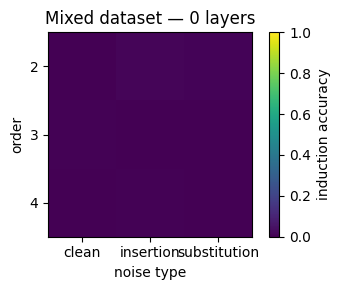

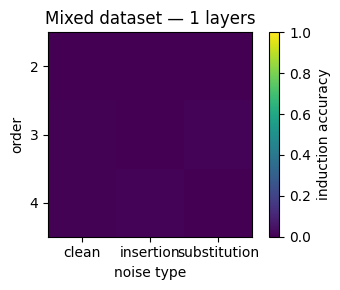

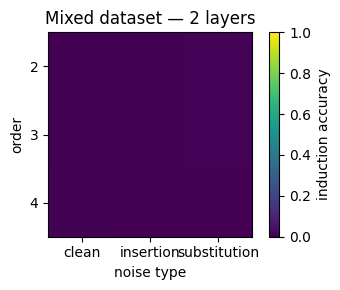

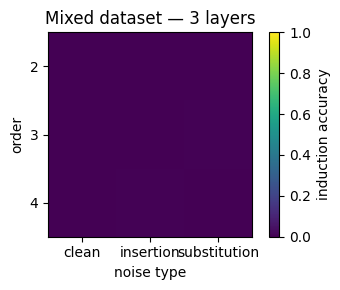

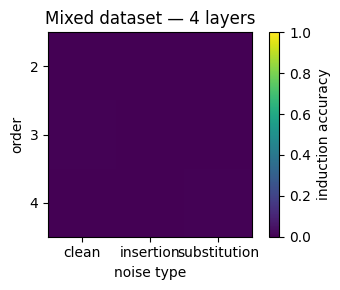

In [16]:

# one heatmap (order x noise_type) per depth
orders = [2, 3, 4]
for L in CONFIG["layer_counts"]:
    sub = mixed_df[mixed_df.num_layers == L]
    pivot = sub.pivot(index="order", columns="noise_type", values="accuracy").reindex(index=orders, columns=noise_order)
    plt.figure(figsize=(4, 3))
    plt.imshow(pivot.values, cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="induction accuracy")
    plt.xticks(range(len(noise_order)), noise_order)
    plt.yticks(range(len(orders)), orders)
    plt.xlabel("noise type")
    plt.ylabel("order")
    plt.title(f"Mixed dataset — {L} layers")
    plt.tight_layout()
    plt.show()



### 7b. Per-head attention-offset profile

For the deepest mixed-dataset model, we look at *what relative offset each
head actually attends to* at induction query positions: for every trigger's
`query_pos`, take `argmax` over the attention row and record
`query_pos - argmax_position`. If the shift-head hypothesis is right, early
layer heads should cluster tightly around a *fixed* offset (`-1`, `-2`, `-3`,
...), and later "induction" heads should show a *spread* of offsets across
different triggers (evidence they're dynamically switching between composed
shift heads rather than always reading from `-1`).


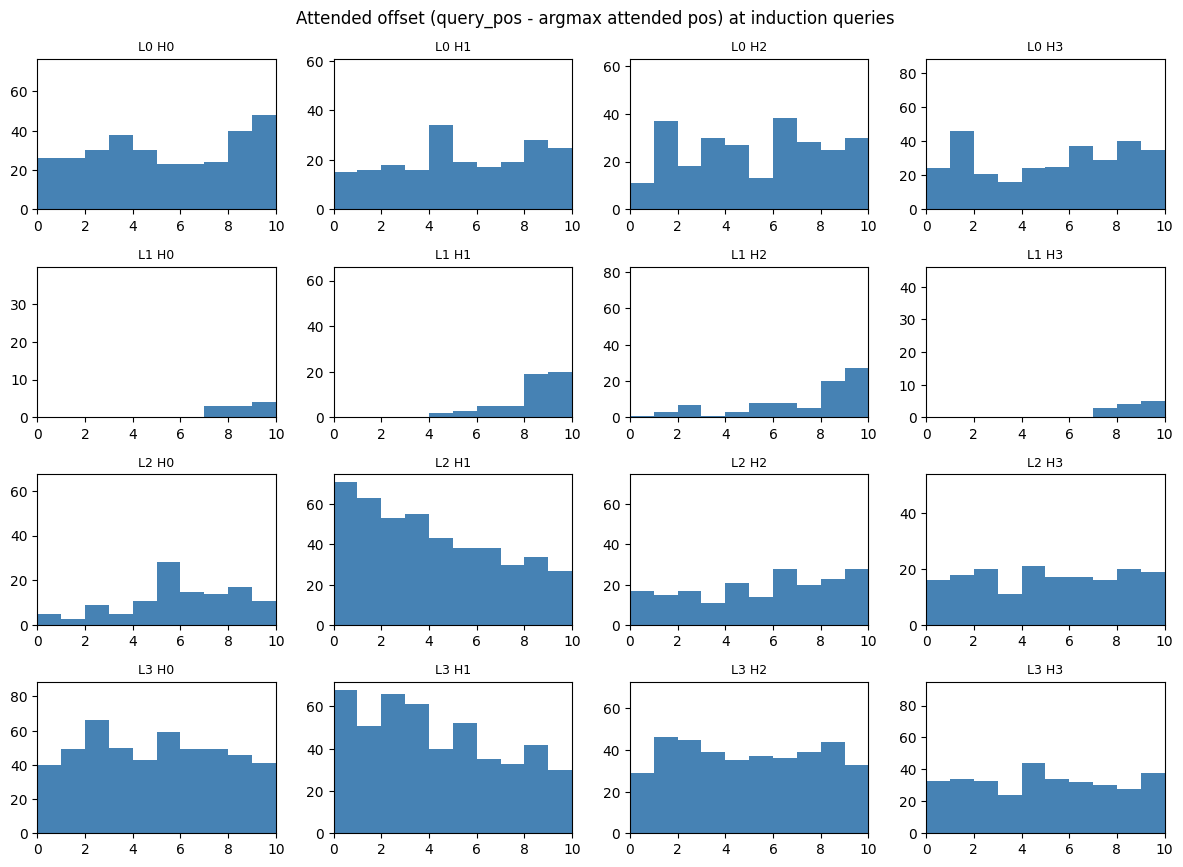

In [17]:

@torch.no_grad()
def collect_attention_offsets(model, tokens, events, max_sequences=500):
    '''For each layer/head, returns a list of (query_pos - argmax_attended_pos)
    offsets measured specifically at induction query positions.'''
    model.eval()
    n = min(max_sequences, tokens.shape[0])
    tok_t = torch.as_tensor(tokens[:n], dtype=torch.long).to(DEVICE)
    _, all_attn = model(tok_t)  # list of (n, num_heads, T, T) per layer
    offsets = defaultdict(list)  # (layer, head) -> list of offsets
    for i in range(n):
        for ev in events[i]:
            q = ev.query_pos if hasattr(ev, "query_pos") else ev["query_pos"]
            for layer_idx, attn in enumerate(all_attn):
                for head_idx in range(attn.shape[1]):
                    row = attn[i, head_idx, q]  # attention distribution at query_pos
                    attended_pos = int(row.argmax().item())
                    offsets[(layer_idx, head_idx)].append(q - attended_pos)
    return offsets

if DEEPEST_L > 0:
    offset_data = collect_attention_offsets(mixed_models[DEEPEST_L], mixed_tok_va, mixed_ev_va)

    fig, axes = plt.subplots(DEEPEST_L, CONFIG["num_heads"], figsize=(3 * CONFIG["num_heads"], 2.2 * DEEPEST_L), squeeze=False)
    for layer_idx in range(DEEPEST_L):
        for head_idx in range(CONFIG["num_heads"]):
            ax = axes[layer_idx][head_idx]
            offs = offset_data.get((layer_idx, head_idx), [])
            ax.hist(offs, bins=range(0, 12), color="steelblue")
            ax.set_title(f"L{layer_idx} H{head_idx}", fontsize=9)
            ax.set_xlim(0, 10)
    fig.suptitle("Attended offset (query_pos - argmax attended pos) at induction queries")
    fig.tight_layout()
    plt.show()
else:
    print("DEEPEST_L == 0, no attention heads to profile.")



## 8. K-composition Frobenius-norm analysis

This reuses the *same detection method the original paper uses for previous-token
→ induction head composition*, generalized to look for composition between
**every pair of layers**, not just adjacent ones, and to summarize it as a
single normalized score per `(early head, late head)` pair:

```
K-comp(h1 -> h2) = || OV(h1) @ QK(h2) ||_F / ( || OV(h1) ||_F * || QK(h2) ||_F )
```

where `OV(h1) = W_V[h1] @ W_O[h1]` is head h1's (embed_dim x embed_dim) output
circuit and `QK(h2) = W_Q[h2] @ W_K[h2]^T` is head h2's (embed_dim x embed_dim)
query-key circuit, both restricted to that head's slice of the residual
stream. A high score for an early head that we independently found (via
Section 7b) to attend at a fixed offset, paired with several *different*
later heads, would be the "K-composition with several shift heads" evidence
your hypothesis predicts — as opposed to one early head composing strongly
with only one later head (single previous-token-head story).

This is a simplified reimplementation for exploration, not a rigorous replication
of the paper's exact normalization — treat the absolute numbers as relative /
comparative, not as validated ground truth.


In [18]:

def get_head_matrices(model, layer_idx, head_idx):
    '''Pulls out this head's slice of W_Q, W_K, W_V, W_O from an
    AblatableSelfAttention module (all Linear layers store weight as
    [out_features, in_features], i.e. y = W x).'''
    attn = model.blocks[layer_idx].attn
    hd = attn.head_dim
    sl = slice(head_idx * hd, (head_idx + 1) * hd)
    W_Q = attn.q_proj.weight[sl, :].detach().cpu()   # (head_dim, embed_dim)
    W_K = attn.k_proj.weight[sl, :].detach().cpu()   # (head_dim, embed_dim)
    W_V = attn.v_proj.weight[sl, :].detach().cpu()   # (head_dim, embed_dim)
    W_O = attn.out_proj.weight[:, sl].detach().cpu() # (embed_dim, head_dim)
    return W_Q, W_K, W_V, W_O


def k_composition_score(model, layer1, head1, layer2, head2):
    '''Normalized Frobenius-norm composition score between an earlier
    head's OV circuit and a later head's QK circuit, both expressed in the
    embed_dim x embed_dim residual-stream basis.'''
    _, _, W_V1, W_O1 = get_head_matrices(model, layer1, head1)
    W_Q2, W_K2, _, _ = get_head_matrices(model, layer2, head2)

    OV1 = W_V1.T @ W_O1.T          # (embed_dim, embed_dim), maps residual -> residual
    QK2 = W_Q2.T @ W_K2            # (embed_dim, embed_dim)

    num = torch.norm(OV1 @ QK2, p="fro")
    denom = torch.norm(OV1, p="fro") * torch.norm(QK2, p="fro")
    return (num / denom).item() if denom > 0 else float("nan")


if DEEPEST_L >= 2:
    comp_rows = []
    for layer1 in range(DEEPEST_L):
        for layer2 in range(layer1 + 1, DEEPEST_L):
            for head1 in range(CONFIG["num_heads"]):
                for head2 in range(CONFIG["num_heads"]):
                    score = k_composition_score(mixed_models[DEEPEST_L], layer1, head1, layer2, head2)
                    comp_rows.append({
                        "early_layer": layer1, "early_head": head1,
                        "late_layer": layer2, "late_head": head2,
                        "score": score,
                    })
    comp_df = pd.DataFrame(comp_rows)
    comp_df.sort_values("score", ascending=False).head(20)
else:
    comp_df = pd.DataFrame()
    print("Need at least 2 attention layers for K-composition; skipping.")


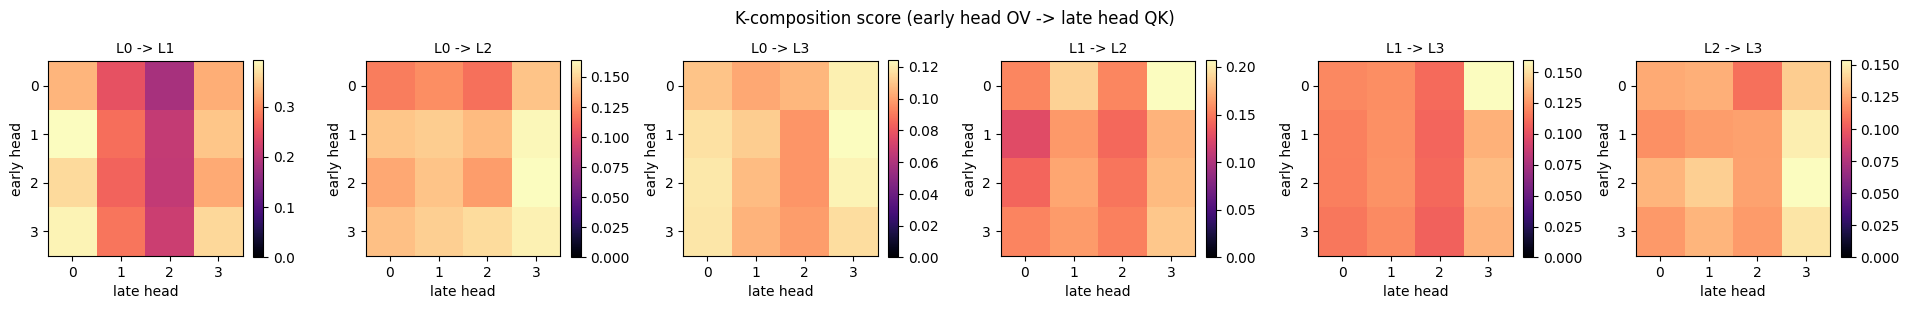

In [19]:

# heatmap for each (early_layer, late_layer) pair: rows=early head, cols=late head
if len(comp_df):
    layer_pairs = comp_df[["early_layer", "late_layer"]].drop_duplicates().values.tolist()
    n_pairs = len(layer_pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(3.2 * n_pairs, 3), squeeze=False)
    for i, (l1, l2) in enumerate(layer_pairs):
        sub = comp_df[(comp_df.early_layer == l1) & (comp_df.late_layer == l2)]
        pivot = sub.pivot(index="early_head", columns="late_head", values="score")
        ax = axes[0][i]
        im = ax.imshow(pivot.values, cmap="magma", vmin=0)
        ax.set_title(f"L{l1} -> L{l2}", fontsize=10)
        ax.set_xlabel("late head")
        ax.set_ylabel("early head")
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle("K-composition score (early head OV -> late head QK)")
    fig.tight_layout()
    plt.show()



## Wrap-up

Everything you need to dig back in later is sitting in plain DataFrames /
dicts in this kernel:

- `phase1_df` — induction accuracy by `(num_layers, order)`
- `phase2_df` — induction accuracy by `(num_layers, noise_type)` at order=4
- `ablation_df` — accuracy drop by `(layer, head, noise_type)` for the deepest
  phase-2 model
- `mixed_df` — induction accuracy by `(num_layers, order, noise_type)` on the
  multiplexed dataset
- `offset_data` — raw attended-offset samples per `(layer, head)` from the
  deepest mixed-dataset model
- `comp_df` — K-composition scores per `(early_layer, early_head, late_layer, late_head)`

`phase1_models`, `phase2_models`, and `mixed_models` (dicts keyed by depth)
hold the actual trained `AttentionOnlyTransformer` instances if you want to
probe them further (e.g. run `get_head_matrices` / `k_composition_score` on
combinations we didn't already sweep, or re-run `predict_next_tokens` with a
custom `ablation_mask` for a specific multi-head ablation).

Things worth increasing before trusting the plots for real conclusions:
`CONFIG["epochs"]`, `CONFIG["n_isolated"]/n_skip/n_mixed`, and possibly
`embed_dim`/`num_heads` if the deepest models aren't cleanly separating from
the shallow ones.
